In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import impute
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV

from scipy.stats import chi2_contingency

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import TomekLinks

import shap

from funcs import *

set_config(transform_output="pandas")
pd.set_option('future.no_silent_downcasting', True)

# Cargar Datos
Aqui dejamos adjunta la [fuente de los datos](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction).

In [2]:
url = 'https://raw.githubusercontent.com/AitzolSa/dataset/619ecb7ffa2bdfcfb5a589fb8266bcf0db15250d/archive.zip'

print("Descargando y leyendo el dataset...")
X = pd.read_csv(url, compression='zip')

print("Datos cargados con exito:")
X.head()

Descargando y leyendo el dataset...
Datos cargados con exito:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


# Dividir Train, Val y Test

In [3]:
# Dividimos train, test y validacion
semilla = 69

y = X.fraudulent
X_features = X.drop('fraudulent', axis=1)
X_resto, X_test, y_resto, y_test = model_selection.train_test_split(
    X_features, y, random_state=semilla, stratify=y, test_size=0.1
)
X_train, X_val, y_train, y_val = model_selection.train_test_split(
    X_resto, y_resto, random_state=semilla, stratify=y_resto, test_size=0.2
)

print("Train:")
print(X_train.describe())
print()

print("Val:")
print(X_val.describe())
print()

print("Test:")
print(X_test.describe())

Train:
             job_id  telecommuting  has_company_logo  has_questions
count  12873.000000   12873.000000      12873.000000   12873.000000
mean    8919.432533       0.042880          0.796784       0.492737
std     5167.644356       0.202595          0.402408       0.499967
min        2.000000       0.000000          0.000000       0.000000
25%     4408.000000       0.000000          1.000000       0.000000
50%     8935.000000       0.000000          1.000000       0.000000
75%    13380.000000       0.000000          1.000000       1.000000
max    17880.000000       1.000000          1.000000       1.000000

Val:
             job_id  telecommuting  has_company_logo  has_questions
count   3219.000000    3219.000000       3219.000000    3219.000000
mean    8991.802423       0.042249          0.788444       0.483691
std     5157.263804       0.201188          0.408475       0.499812
min        1.000000       0.000000          0.000000       0.000000
25%     4594.500000       0.000000 

# Modelo Definitivo

In [4]:
col_id = ["job_id"]

columnas_texto_mejor = [
    "company_profile",
    "description",
    "benefits"
]

cols_base_categoricas = [
    "title",
    "location",
    "department",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

cols_numericas = [
    "telecommuting",
    "has_company_logo",
    "has_questions"
]

col_salario = ["salary_range"]

# Columnas categóricas que se usan en esta prueba
cols_categoricas_prueba = cols_base_categoricas + columnas_texto_mejor

# Número total de variables que entran antes del selector
n_variables_total = len(cols_categoricas_prueba) + len(cols_numericas)

transformer = ColumnTransformer(transformers=[
    ("imputar_categoricas",
        impute.SimpleImputer(strategy="constant", fill_value="unk"),
        cols_categoricas_prueba),

    ("imputar_salario",
        discretizador_salario(),
        col_salario),

    ("imputar_numericas",
        impute.SimpleImputer(strategy="constant", fill_value=-1),
        cols_numericas),

    ("dropear_id",
        "drop",
        col_id)
],
    remainder="drop",
    verbose_feature_names_out=False
)


numerizar = ColumnTransformer(transformers=[
    ("target_enc",
        preprocessing.TargetEncoder(smooth="auto", random_state=semilla),
        cols_categoricas_prueba + col_salario),

    ("scaler_numericas",
        preprocessing.StandardScaler(),
        cols_numericas)
],
    remainder="drop",
    verbose_feature_names_out=False
)

pipe = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar", minusculizar()),
    ("quitarSimbolos", quitar_simbolos()),
    ("quitarTildes", quitar_tildes()),
    ("rellenar", transformer),
    ("numerizar_y_escalar", numerizar),
    ("seleccion_variables", SelectorCorrelacion(k=9)),
    ("limpieza_ruido",TomekLinks()),
    ("modelo", KNeighborsClassifier())
])

## Buscar mejores Hiperparametros

In [5]:
params = {
    "modelo__n_neighbors": [1,3,5,7],
    "modelo__weights": ["uniform",  "distance"],
    "modelo__p": [1,1.5,2,3]
}

grid = GridSearchCV(
    estimator = pipe,
    param_grid = params,
    scoring = "average_precision"
)

print("Empezando train")
grid.fit(X_resto, y_resto)
print()


print("Mejor modelo obtenido con los siguientes parametros")
best_params = grid.best_params_

for param, value in best_params.items():
    print("{}: {}".format(param,value))

print()

Empezando train

Mejor modelo obtenido con los siguientes parametros
modelo__n_neighbors: 7
modelo__p: 1.5
modelo__weights: distance



## Entrenamiento del modelo definitivo para KNN

Fiteando modelo final
Empezando a predecir train
Empezando a predecir val
Resultado en val: 0.8676549227831152


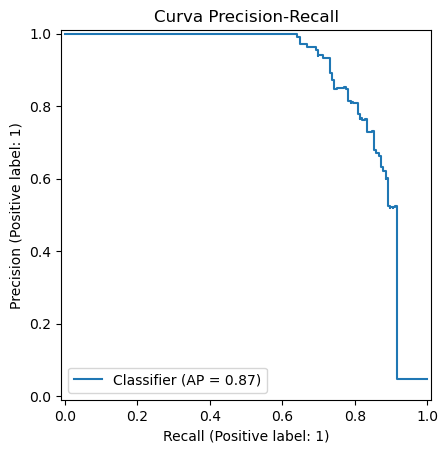

In [7]:
knn_final = Pipeline([
    ("limpiaEspacios", limpiar_espacios()),
    ("minusculizar", minusculizar()),
    ("quitarSimbolos", quitar_simbolos()),
    ("quitarTildes", quitar_tildes()),
    ("rellenar", transformer),
    ("numerizar_y_escalar", numerizar),
    ("seleccion_variables", SelectorCorrelacion(k=9)),
    ("limpieza_ruido",TomekLinks()),
    ("modelo", KNeighborsClassifier(n_neighbors = 7, p = 1.5, weights = "distance"))
])

print("Fiteando modelo final")
knn_final.fit(X_train, y_train)

print("Empezando a predecir train")
probs_train = knn_final.predict_proba(X_train)[:, 1]

print("Empezando a predecir val")
probs_val = knn_final.predict_proba(X_val)[:, 1]

pr_auc_val = metrics.average_precision_score(
    y_val,
    probs_val
)

print("Resultado en val: {}".format(pr_auc_val))

metrics.PrecisionRecallDisplay.from_predictions(
    y_val,
    probs_val
)

plt.title("Curva Precision-Recall")
plt.show()

# Relacion entre variables tras procesar

In [8]:
prep = knn_final[:-3]

X_corr_1 = prep.transform(X_val)

tl = TomekLinks()

X_corr_2,y_corr = tl.fit_resample(X_corr_1, y_val)

X_corr_2["fraudulent"] = y_corr

corr_matrix = X_corr_2.corr()

corr_matrix

,title,location,department,employment_type,required_experience,required_education,industry,function,company_profile,description,benefits,salary_range,telecommuting,has_company_logo,has_questions,fraudulent
title,1.000000,0.233092,0.371464,0.072596,0.022665,0.075579,0.198493,0.097504,0.519826,0.678236,0.586818,0.027305,-0.001708,-0.117598,-0.067069,0.627922
location,0.233092,1.000000,0.276267,0.035642,0.037030,0.040388,0.263150,0.087477,0.319527,0.182909,0.316474,0.048174,0.014886,-0.113740,-0.076882,0.361965
department,0.371464,0.276267,1.000000,0.002414,0.023624,0.032429,0.122411,0.159731,0.277933,0.303870,0.405083,0.084738,0.022515,-0.078599,-0.058084,0.323557
employment_type,0.072596,0.035642,0.002414,1.000000,0.257138,0.216527,0.095674,0.063806,0.033942,0.065656,0.058534,-0.127925,0.007565,-0.036538,0.019816,0.088145
required_experience,0.022665,0.037030,0.023624,0.257138,1.000000,0.267625,0.068787,0.107954,-0.018514,0.006000,0.004424,-0.127159,0.014546,-0.103423,-0.077577,0.077467
required_education,0.075579,0.040388,0.032429,0.216527,0.267625,1.000000,0.129045,0.196471,0.058874,0.221079,0.073427,-0.052050,0.122378,-0.080555,-0.065221,0.177567
industry,0.198493,0.263150,0.122411,0.095674,0.068787,0.129045,1.000000,0.163330,0.188189,0.144333,0.237981,0.019895,-0.017651,-0.089238,-0.032987,0.282143
function,0.097504,0.087477,0.159731,0.063806,0.107954,0.196471,0.163330,1.000000,0.083222,0.124720,0.066198,0.042314,0.033415,-0.074209,-0.049737,0.182754
company_profile,0.519826,0.319527,0.277933,0.033942,-0.018514,0.058874,0.188189,0.083222,1.000000,0.458333,0.532153,0.074913,0.053859,-0.302726,-0.077726,0.619967
description,0.678236,0.182909,0.303870,0.065656,0.006000,0.221079,0.144333,0.124720,0.458333,1.000000,0.580319,0.001827,0.040568,-0.140578,-0.072548,0.609570


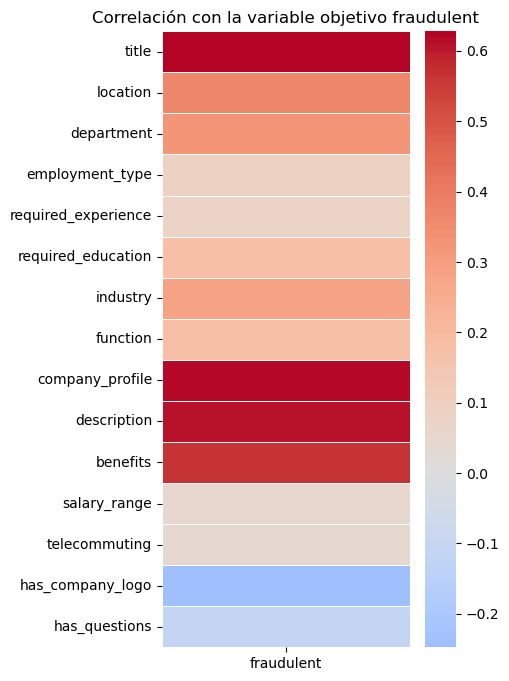

In [9]:
correlaciones_objetivo = corr_matrix[["fraudulent"]].drop("fraudulent")

plt.figure(figsize=(4, 8))

sns.heatmap(
    correlaciones_objetivo,
    cmap="coolwarm",
    center=0,
    annot=False,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlación con la variable objetivo fraudulent")
plt.show()

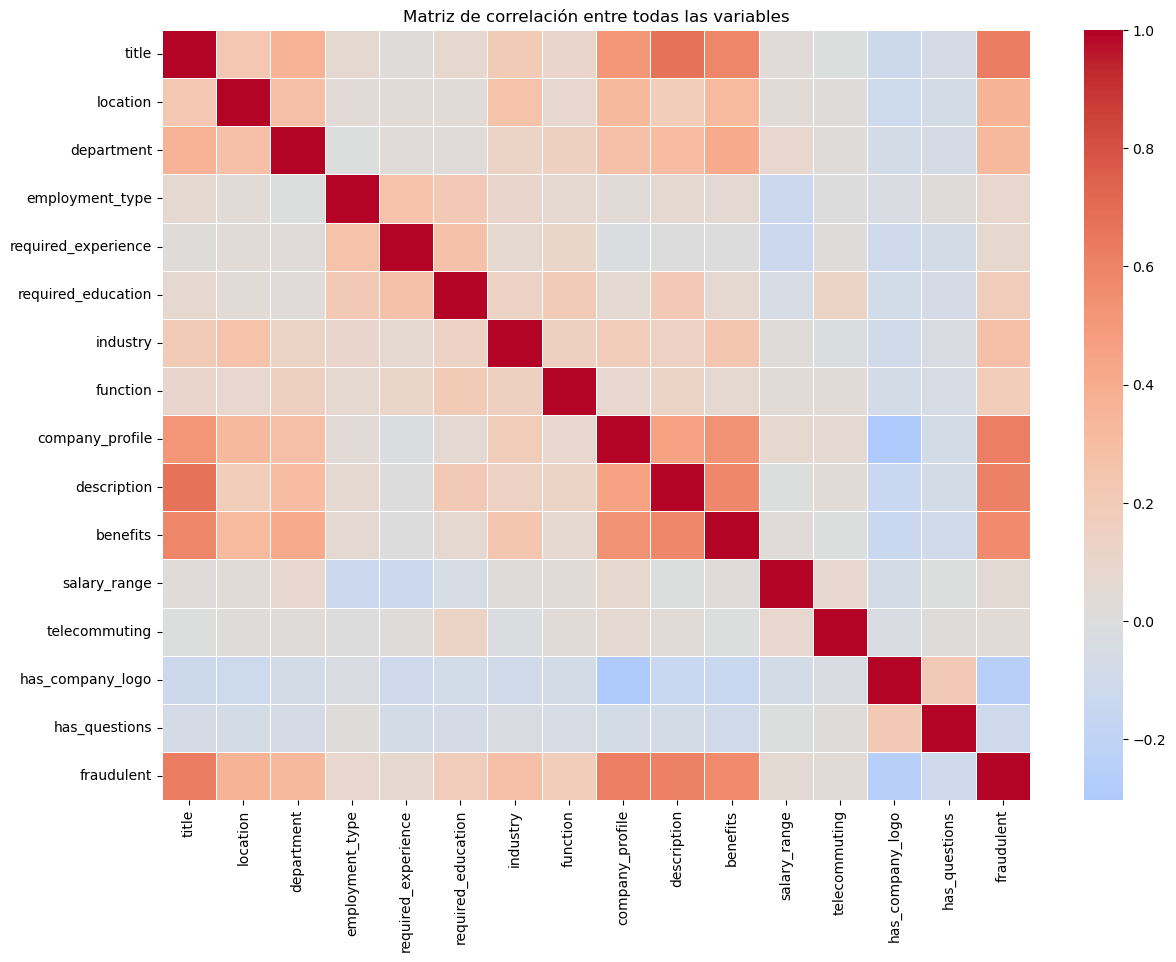

In [10]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación entre todas las variables")
plt.show()

# Elegir Mejor Umbral

In [11]:
def clasf_umbral(probs, umbral=0.5):
    preds = np.zeros_like(probs)
    preds[probs > umbral] = 1
    return preds

precision, recall, umbrals = metrics.precision_recall_curve(y_train, probs_train)

rend_umbrals = np.empty_like(umbrals)

for i, umbral in enumerate(umbrals):
    preds = clasf_umbral(probs_val, umbral=umbral)
    
    rend_umbrals[i] = metrics.f1_score(y_val, preds)

indBestUmbral = np.argmax(rend_umbrals)

bestUmbral = umbrals[indBestUmbral]

print('Mejor umbral={:.3f}, Fscore en validacion={:.5f}'.format(bestUmbral, rend_umbrals[indBestUmbral]))

Mejor umbral=0.738, Fscore en validacion=0.82014


# Rendimiento en Test

El rendimiento obtenido en test ha sido: 0.810126582278481


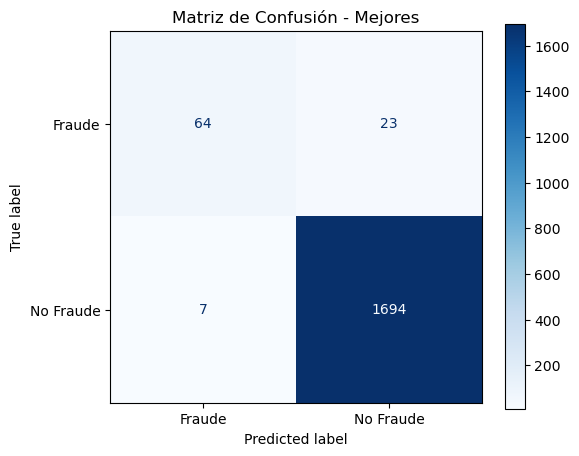

In [12]:
probs_test = grid.predict_proba(X_test)[:,1]

preds_test = np.where(probs_test > bestUmbral, 1, 0)

score_test =  metrics.f1_score(y_test, preds_test)

print("El rendimiento obtenido en test ha sido: {}".format(score_test))

fig, ax = plt.subplots(figsize=(6, 5))
metrics.ConfusionMatrixDisplay.from_predictions(
    1 - y_test, 1 - preds_test, 
    display_labels=["Fraude", "No Fraude"],
    cmap="Blues", ax=ax
)
plt.title("Matriz de Confusión - Mejores")
plt.show()

# Interpretabilidad

Inicializando explainer de SHAP sobre las mejores 10 variables...
Calculando valores SHAP (esto puede tardar un poco)...


  0%|          | 0/100 [00:00<?, ?it/s]

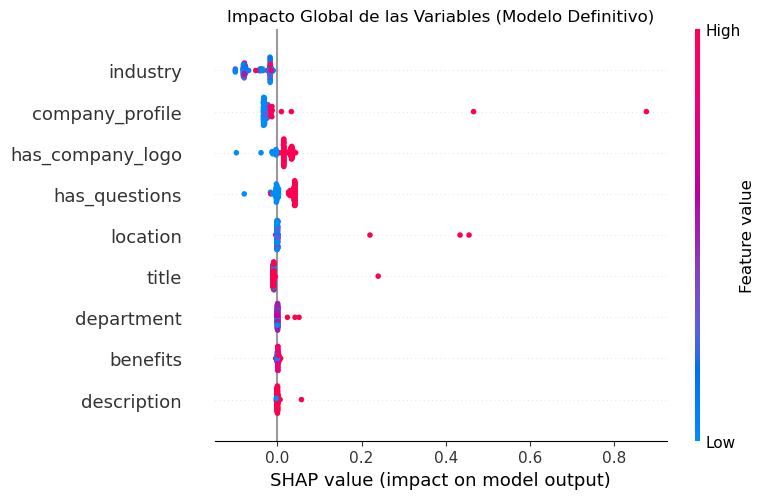

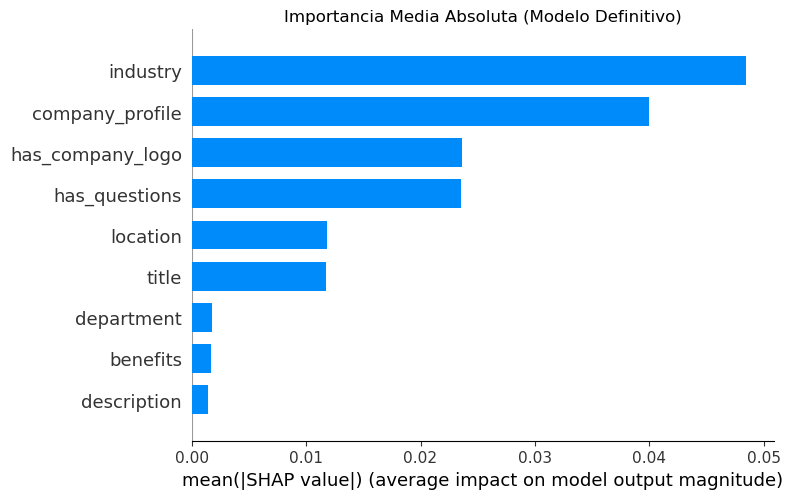


ExplicaX_val_test_defndo la predicción local para la muestra en la posición 0:


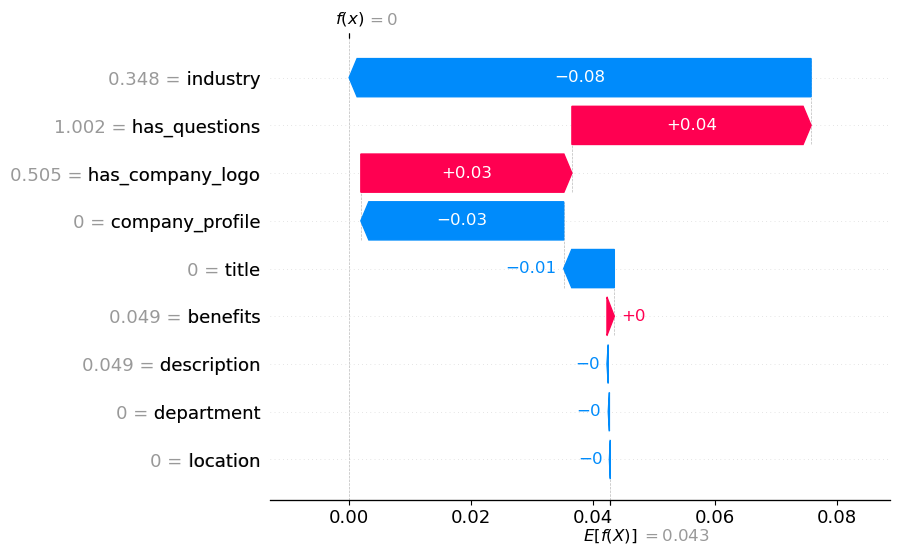

In [13]:
shap.initjs()

# Extraer el preprocesador (todo hasta el selector incluido) y el modelo final
preprocesador_def = knn_final[:-1]
modelo_knn_def = knn_final.named_steps['modelo']
X_train_trans_def,_ = preprocesador_def.fit_resample(X_train,y_train)
X_test_trans_def,_ = preprocesador_def.fit_resample(X_test,y_test)

if isinstance(X_train_trans_def, pd.DataFrame):
    nombres_columnas = X_train_trans_def.columns
else:
    try:
        nombres_columnas = preprocesador_def.get_feature_names_out()
    except:
        nombres_columnas = [f"Var_Seleccionada_{i}" for i in range(X_train_trans_def.shape[1])]
    
    X_train_trans_def = pd.DataFrame(X_train_trans_def, columns=nombres_columnas)
    X_val_trans_def = pd.DataFrame(X_val_trans_def, columns=nombres_columnas)

def predict_proba_fraude_def(X):
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=nombres_columnas)
    return knn_final[-1].predict_proba(X)[:, 1]

background_def = shap.sample(X_train_trans_def, 50, random_state=semilla)

print("Inicializando explainer de SHAP sobre las mejores 10 variables...")
explainer_def = shap.KernelExplainer(predict_proba_fraude_def, background_def)

X_test_sample_def = shap.sample(X_test_trans_def, 100, random_state=semilla)

print("Calculando valores SHAP (esto puede tardar un poco)...")
shap_values_def = explainer_def.shap_values(X_test_sample_def)

# --- VISUALIZACIONES ---

# Gráfico 1: Summary Plot
plt.figure(figsize=(10, 6))
plt.title("Impacto Global de las Variables (Modelo Definitivo)")
shap.summary_plot(shap_values_def, X_test_sample_def, show=False)
plt.show()

# Gráfico 2: Bar Plot
plt.figure(figsize=(10, 6))
plt.title("Importancia Media Absoluta (Modelo Definitivo)")
shap.summary_plot(shap_values_def, X_test_sample_def, plot_type="bar", show=False)
plt.show()

# Gráfico 3: Waterfall Plot para el primer caso de la muestra
indice_ejemplo = 0
print(f"\nExplicaX_val_test_defndo la predicción local para la muestra en la posición {indice_ejemplo}:")

shap_exp_def = shap.Explanation(
    values=shap_values_def[indice_ejemplo],
    base_values=explainer_def.expected_value,
    data=X_test_sample_def.iloc[indice_ejemplo],
    feature_names=X_test_sample_def.columns
)

shap.plots.waterfall(shap_exp_def)